# 01 — Exploración del dataset

**GymPulse AI · Sprint 1 · Equipo #31**

Exploración interactiva de `clean_gym_data.csv`.

| Métrica | Valor esperado |
|---------|----------------|
| Registros | 3,564 |
| Países | 132 |
| Años | 2000 – 2026 |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from gympulse.config import DEFAULT_CSV

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv(DEFAULT_CSV)
df.head()

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,Angola,2000,Africa,95521.0,0.3873,5731259.0,204.0,0.0059,0.5051,0.0470,563.7338,16194869.0,5.0,0.2219
1,Angola,2001,Africa,103840.0,0.3939,6230372.0,222.0,0.0062,0.5172,0.0496,533.5862,16747208.0,5.0,0.2192
2,Angola,2002,Africa,121093.0,0.4003,7265583.0,249.0,0.0070,0.5289,0.0522,999.0659,17327699.0,5.0,0.2164
3,Angola,2003,Africa,142783.0,0.4065,8566966.0,281.0,0.0080,0.5400,0.0548,1133.6633,17943712.0,5.0,0.2137
4,Angola,2004,Africa,179615.0,0.4124,10776918.0,325.0,0.0097,0.5504,0.0574,1451.4712,18600423.0,5.0,0.2110


## Resumen general

In [2]:
summary = {
    "registros": len(df),
    "paises": df["country"].nunique(),
    "regiones": df["region"].nunique(),
    "año_min": int(df["year"].min()),
    "año_max": int(df["year"].max()),
    "columnas": len(df.columns),
}
pd.Series(summary)

registros    3564
paises        132
regiones        6
año_min      2000
año_max      2026
columnas       14
dtype: int64

## Distribución por región y año

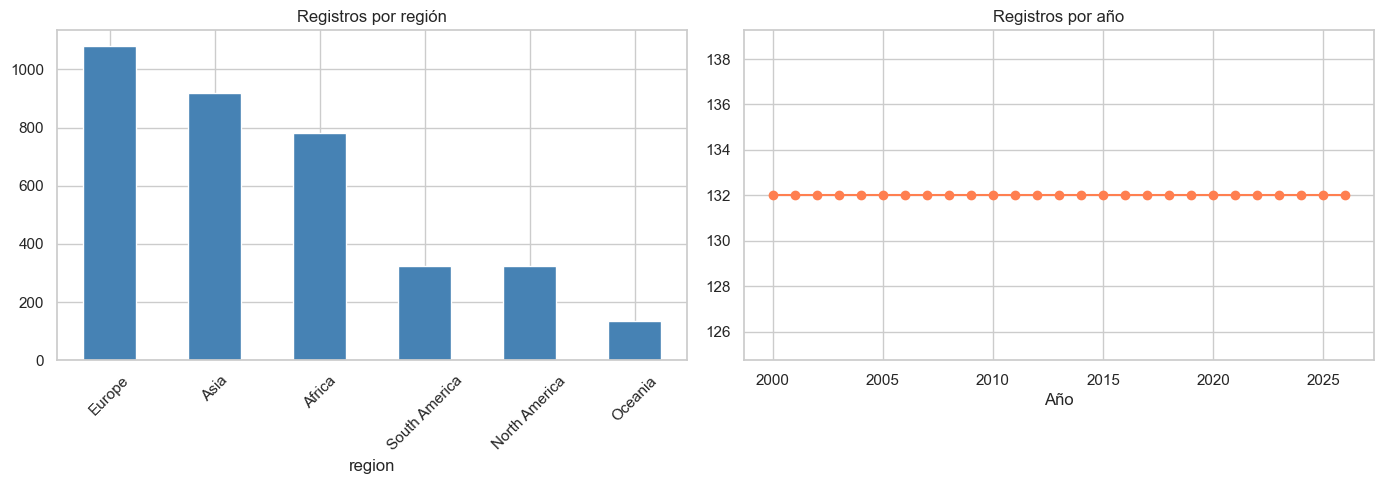

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["region"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Registros por región")
axes[0].tick_params(axis="x", rotation=45)

df.groupby("year").size().plot(ax=axes[1], color="coral", marker="o")
axes[1].set_title("Registros por año")
axes[1].set_xlabel("Año")

plt.tight_layout()
plt.show()

## Top 10 países por membresías (último año)

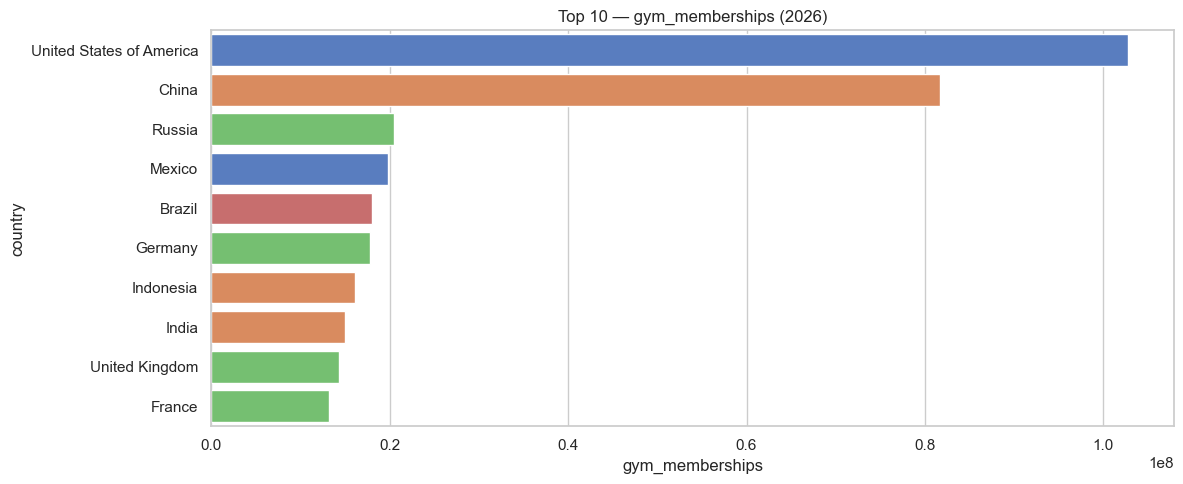

In [4]:
latest = df[df["year"] == df["year"].max()].nlargest(10, "gym_memberships")
sns.barplot(data=latest, y="country", x="gym_memberships", hue="region", dodge=False, legend=False)
plt.title(f"Top 10 — gym_memberships ({int(df['year'].max())})")
plt.tight_layout()
plt.show()